In [1]:
import torch
import json
from ptlpinns.models import model, transfer
from ptlpinns.perturbation import standard
from ptlpinns.odes import forcing, numerical, equations
import numpy as np
import math
import matplotlib.pyplot as plt

/home/jovyan/PTL-PINNs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Problem setup

Underdamped Duffing oscillator with cubic nonlinearity:
$$\ddot{x} + 2\zeta\dot{x} + x + \varepsilon x^3 = 0, \quad x(0)=1,\; \dot{x}(0)=0,\; \zeta=0.5.$$

Epsilon sweep using the pretrained `underdamped_k12` backbone and the
**standard** (non-LPM) perturbation pipeline from `underdamped copy.ipynb`.

In [2]:
train_root = "/home/jovyan/PTL-PINNs/ptlpinns/models/train"

t_span = (0, 10)
N = 500
t_eval = np.linspace(t_span[0], t_span[1], N)

w_0 = 1
zeta = 0.4
ic = [1, 0]
q = [(3, 1)]
p_max = 5
REFINE = 1000

epsilon_values = np.arange(0.05, 2.0, 0.10)
forcing_fn = forcing.zeroes_2D(numpy=True)
forcing_1D = lambda t: np.zeros_like(t)

model_name = "underdamped_k14"

In [3]:
def run_epsilon_sweep(H_dict, training_log, zeta, epsilon_values):
    """Standard-perturbation epsilon sweep (no LPM)."""
    results = {}

    for epsilon in epsilon_values:
        ode = equations.ode_oscillator_1D(
            w_0=w_0, zeta=zeta,
            forcing_1D=forcing_1D,
            q=q, epsilon=epsilon,
        )

        error = standard.compute_error_per_order_standard(
            H_dict=H_dict,
            training_log=training_log,
            w_0=w_0,
            zeta=zeta,
            epsilon=epsilon,
            p_max=p_max,
            ic=ic,
            forcing_function=forcing_fn,
            q=q,
            ode=ode,
            t_eval=t_eval,
            refine=REFINE,
        )

        results[epsilon] = {"error": error}

    return results

### Epsilon sweep

Load the underdamped backbone, build $H$, and run the standard perturbation
pipeline up to $p_{\max}=5$. MAE is measured against a high-accuracy numerical
reference on the PTL-PINN time grid.

In [4]:
model_path = f"{train_root}/{model_name}"
pinn_model, training_log = model.load_model(
    model_path, f"model_{model_name}.pth",
)
H_dict = transfer.compute_H_dict(
    pinn_model, N=N, bias=True, t_span=t_span,
)

print(f"Running underdamped sweep (zeta={zeta}, model={model_name}) ...")
results = run_epsilon_sweep(
    H_dict, training_log, zeta, epsilon_values,
)
print(f"done — {len(results)} epsilon values")

14 True True True 1.0 16 [128, 128, 256]
Running underdamped sweep (zeta=0.4, model=underdamped_k14) ...
done — 20 epsilon values


### MAE @ $p = p_{\max}$ vs $\varepsilon^{p_{\max}}$ — normalised comparison

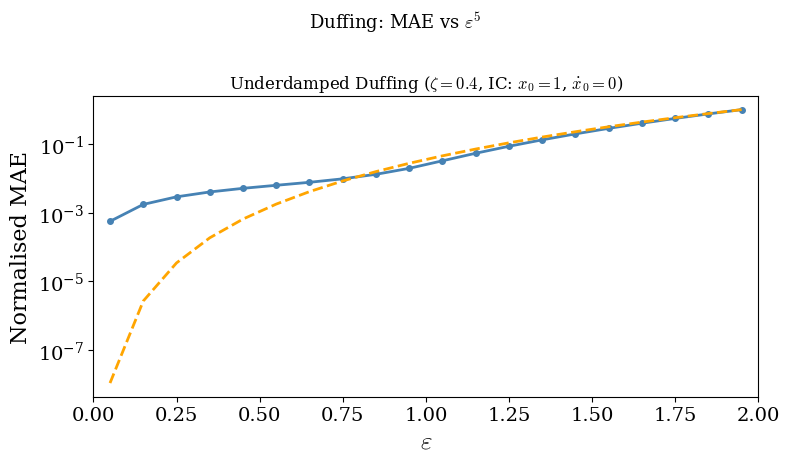

In [5]:
sweep_eps = np.array(sorted(results.keys()))
sweep_maes = np.array([results[eps]["error"][-1] for eps in sweep_eps])
sweep_eps_ref = sweep_eps ** p_max

mae_norm = sweep_maes / np.max(sweep_maes)
ref_norm = sweep_eps_ref / np.max(sweep_eps_ref)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(sweep_eps, mae_norm, "o-", linewidth=2, markersize=4,
        color="steelblue", label=rf"MAE @ $p={p_max}$")
ax.plot(sweep_eps, ref_norm, "--", linewidth=2,
        color="orange", label=rf"$\varepsilon^{{{p_max}}}$")

ax.set_title(
    rf"Underdamped Duffing ($\zeta={zeta}$, IC: $x_0=1$, $\dot{{x}}_0=0$)",
    fontsize=12,
)
ax.set_yscale("log")
ax.set_xlim(0, 2.0)
ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel(r"$\varepsilon$", fontsize=18)
ax.set_ylabel("Normalised MAE", fontsize=16)
#ax.grid(True, alpha=0.3, which="both")
#ax.legend(frameon=False, fontsize=10, loc="upper left")

fig.suptitle(
    rf"Duffing: MAE vs $\varepsilon^{{{p_max}}}$",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()